<a href="https://colab.research.google.com/github/assu786/MACHINE-LEARNING/blob/main/peoplerecognization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
!pip install opencv-python-headless numpy

In [21]:
!wget https://pjreddie.com/media/files/yolov3.weights

--2025-12-30 09:01:14--  https://pjreddie.com/media/files/yolov3.weights
Resolving pjreddie.com (pjreddie.com)... 104.21.88.156, 172.67.185.199, 2606:4700:3037::6815:589c, ...
Connecting to pjreddie.com (pjreddie.com)|104.21.88.156|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://data.pjreddie.com/files/yolov3.weights [following]
--2025-12-30 09:01:14--  https://data.pjreddie.com/files/yolov3.weights
Resolving data.pjreddie.com (data.pjreddie.com)... 104.21.88.156, 172.67.185.199, 2606:4700:3030::ac43:b9c7, ...
Connecting to data.pjreddie.com (data.pjreddie.com)|104.21.88.156|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 248007048 (237M) [application/octet-stream]
Saving to: ‘yolov3.weights.1’

yolov3.weights.1    100%[===================>] 236.52M  86.7MB/s    in 2.7s    

2025-12-30 09:01:17 (86.7 MB/s) - ‘yolov3.weights.1’ saved [248007048/248007048]



In [22]:
!wget https://raw.githubusercontent.com/pjreddie/darknet/master/cfg/yolov3.cfg


--2025-12-30 09:01:18--  https://raw.githubusercontent.com/pjreddie/darknet/master/cfg/yolov3.cfg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.109.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 8342 (8.1K) [text/plain]
Saving to: ‘yolov3.cfg.1’

yolov3.cfg.1        100%[===================>]   8.15K  --.-KB/s    in 0s      

2025-12-30 09:01:18 (53.6 MB/s) - ‘yolov3.cfg.1’ saved [8342/8342]



In [23]:
!wget https://github.com/pjreddie/darknet/blob/master/data/coco.names


--2025-12-30 09:01:18--  https://github.com/pjreddie/darknet/blob/master/data/coco.names
Resolving github.com (github.com)... 140.82.112.3
Connecting to github.com (github.com)|140.82.112.3|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/html]
Saving to: ‘coco.names.1’

coco.names.1            [ <=>                ] 186.45K  --.-KB/s    in 0.1s    

2025-12-30 09:01:18 (1.85 MB/s) - ‘coco.names.1’ saved [190923]



In [24]:
from google.colab import files
upload=files.upload()

Saving im.png to im (1).png


In [25]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow


In [26]:
#load yolo model
net=cv2.dnn.readNetFromDarknet('yolov3.cfg','yolov3.weights')
#load coco names
with open('coco.names','r') as f:
 classes=f.read().strip().split("\n")
#get output layers
layer_names=net.getLayerNames()
output_layers=[layer_names[i-1] for i in net.getUnconnectedOutLayers()]
#load image
image=cv2.imread('im.png')
height,width,channels=image.shape

In [27]:
#create blob
blob=cv2.dnn.blobFromImage(image,1/255.0,(416,416),(0,0,0),True,crop=False)
net.setInput(blob)
outputs=net.forward(output_layers)
boxes=[]
confidences=[]

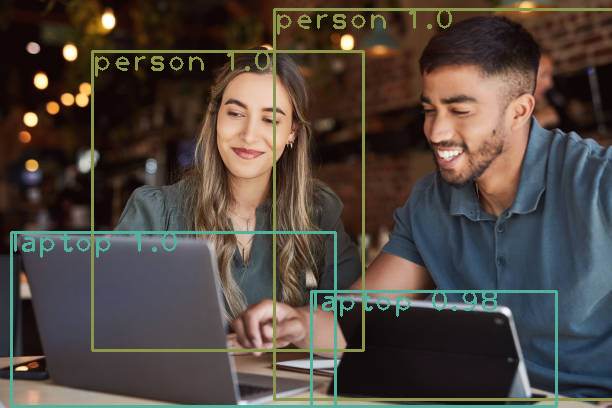

In [28]:
#process detections
boxes = []
confidences = []
class_ids = []

for output in outputs:
    for detection in output:
        scores = detection[5:]
        class_id = np.argmax(scores)
        confidence = scores[class_id]
        if confidence > 0.5:  # Confidence threshold
            center_x = int(detection[0] * width)
            center_y = int(detection[1] * height)
            w = int(detection[2] * width)
            h = int(detection[3] * height)

            x = int(center_x - w / 2)
            y = int(center_y - h / 2)

            boxes.append([x, y, w, h])
            confidences.append(float(confidence))
            class_ids.append(class_id)

# Apply Non-Maximum Suppression (NMS)
indexes = cv2.dnn.NMSBoxes(boxes, confidences, 0.5, 0.4)

# Draw bounding boxes and labels on the image
font = cv2.FONT_HERSHEY_PLAIN
colors = np.random.uniform(0, 255, size=(len(classes), 3))

if len(indexes) > 0:
    for i in indexes.flatten():
        x, y, w, h = boxes[i]
        label = str(classes[class_ids[i]])
        confidence = str(round(confidences[i], 2))
        color = colors[class_ids[i]]
        cv2.rectangle(image, (x, y), (x + w, y + h), color, 2)
        cv2.putText(image, label + " " + confidence, (x, y + 20), font, 2, color, 2)

# Display the result
cv2_imshow(image)